In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
 
%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [4]:
# Генеруємо 300 точок, 4 центри (кластери)
observations, _ = make_blobs(
    n_samples=300, 
    centers=4, 
    cluster_std=0.60, 
    random_state=42
)

# Перевірка результату:
print(f'Розмірність масиву: {observations.shape}')       
print(f'Перші 5 записів:\n{observations[:5]}')

Розмірність масиву: (300, 2)
Перші 5 записів:
[[ -9.1139443    6.81361629]
 [ -9.35457578   7.09278959]
 [ -2.01567068   8.28177994]
 [ -7.01023591  -6.22084348]
 [-10.06120248   6.71867113]]


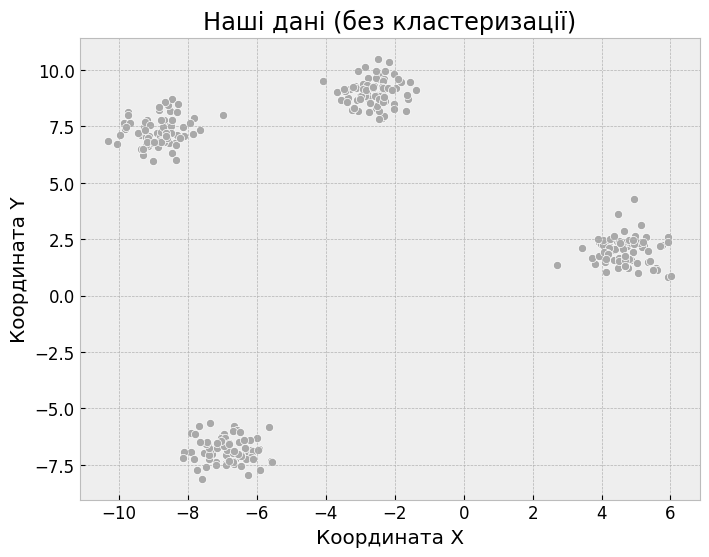

In [5]:
plt.figure(figsize=(8, 6))
plt.scatter(observations[:, 0], observations[:, 1], s=35, color='darkgray', edgecolors='white')
plt.title('Наші дані (без кластеризації)')
plt.xlabel('Координата X')
plt.ylabel('Координата Y')
plt.show()

In [6]:
# Створюємо та навчаємо модель
kmeans_algo = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)

# Запускаємо: алгоритм навчиться і поверне мітки кластерів
predicted_groups = kmeans_algo.fit_predict(observations)

# Перевірка результату:
print(f'Унікальні мітки: {np.unique(predicted_groups)}')
print(f'Центри кластерів (координати):\n{kmeans_algo.cluster_centers_}')
print(f'Значення інерції (J): {kmeans_algo.inertia_:.2f}')

Унікальні мітки: [0 1 2 3]
Центри кластерів (координати):
[[-2.60516878  8.99280115]
 [-6.85126211 -6.85031833]
 [ 4.68687447  2.01434593]
 [-8.83456141  7.24430734]]
Значення інерції (J): 203.89


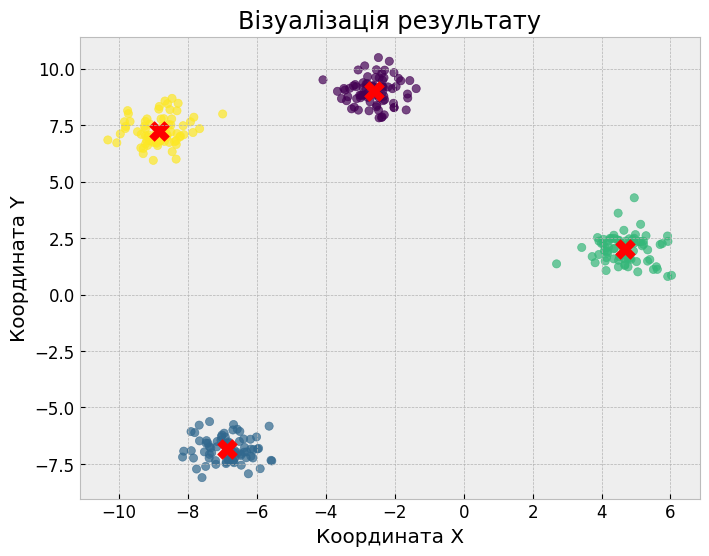

In [8]:
plt.figure(figsize=(8, 6))
# Малюємо точки, розфарбовані за кластерами
plt.scatter(observations[:, 0], observations[:, 1], c=predicted_groups, s=35, cmap='viridis', alpha=0.7)

# Додаємо центроїди
centroids_pos = kmeans_algo.cluster_centers_
plt.scatter(centroids_pos[:, 0], centroids_pos[:, 1], c='red', marker='X', s=200, label='Центроїди')

plt.title("Візуалізація результату")
plt.xlabel('Координата X')
plt.ylabel('Координата Y')
plt.show()

In [9]:
# Оцінка якості
s_avg = silhouette_score(observations, predicted_groups)
print(f"Силуетний коефіцієнт: {s_avg:.4f}")

Силуетний коефіцієнт: 0.8756



ЕКСПЕРИМЕНТ: Кількість кластерів k = 2
Мітки кластерів для k=2: [0 1]
Центроїди:
[[-2.25095191  6.08381814]
 [-6.85126211 -6.85031833]]
Інерція (J) для k=2: 9051.82
Силуетний коефіцієнт для k=2: 0.6155


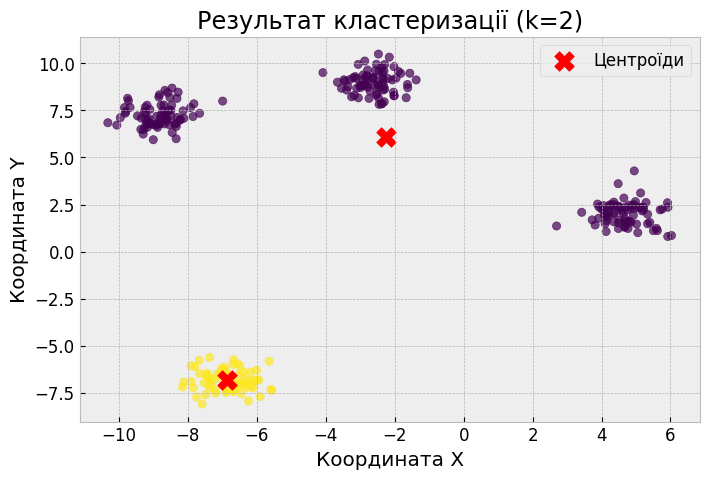


ЕКСПЕРИМЕНТ: Кількість кластерів k = 4
Мітки кластерів для k=4: [0 1 2 3]
Центроїди:
[[-2.60516878  8.99280115]
 [-6.85126211 -6.85031833]
 [ 4.68687447  2.01434593]
 [-8.83456141  7.24430734]]
Інерція (J) для k=4: 203.89
Силуетний коефіцієнт для k=4: 0.8756


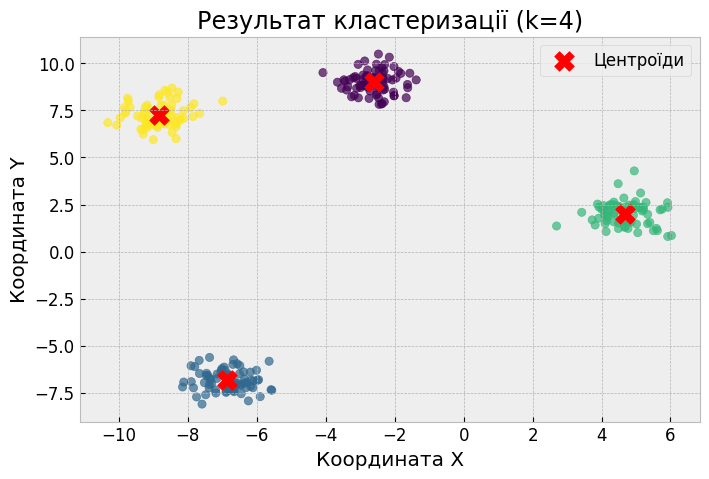


ЕКСПЕРИМЕНТ: Кількість кластерів k = 5
Мітки кластерів для k=5: [0 1 2 3 4]
Центроїди:
[[-8.29999244  7.89902084]
 [ 4.68687447  2.01434593]
 [-6.85126211 -6.85031833]
 [-2.60516878  8.99280115]
 [-9.02895013  7.0062297 ]]
Інерція (J) для k=5: 184.41
Силуетний коефіцієнт для k=5: 0.7552


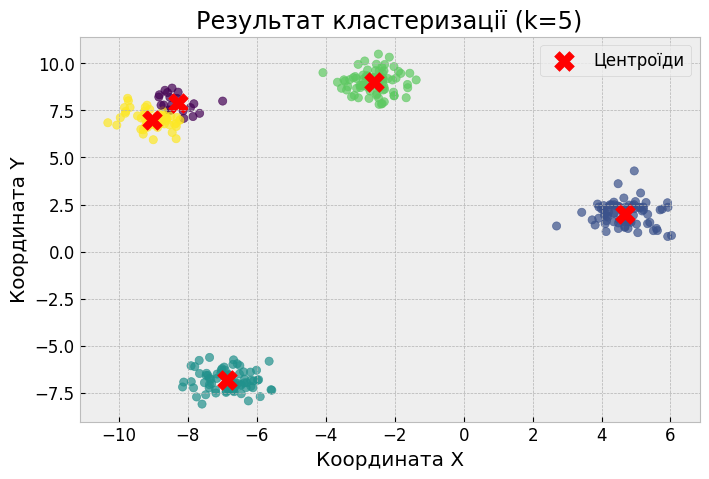

In [11]:
# Список значень k для експерименту
k_values = [2, 4, 5]

for k in k_values:
    print(f"\n" + "="*50)
    print(f"ЕКСПЕРИМЕНТ: Кількість кластерів k = {k}")
    print("="*50)
    
    # 1. Ініціалізація та навчання моделі
    model_exp = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels_exp = model_exp.fit_predict(observations)
    
    # 2. Технічні перевірки:
    print(f'Мітки кластерів для k={k}: {np.unique(labels_exp)}')
    print(f'Центроїди:\n{model_exp.cluster_centers_}')
    print(f'Інерція (J) для k={k}: {model_exp.inertia_:.2f}')
    
    # 3. Обчислення силуетного коефіцієнта
    silhouette_exp = silhouette_score(observations, labels_exp)
    print(f'Силуетний коефіцієнт для k={k}: {silhouette_exp:.4f}')
    
    # 4. Візуалізація результату
    plt.figure(figsize=(8, 5))
    plt.scatter(observations[:, 0], observations[:, 1], c=labels_exp, s=35, cmap='viridis', alpha=0.7)
    
    # Додаємо центри кластерів
    exp_centers = model_exp.cluster_centers_
    plt.scatter(exp_centers[:, 0], exp_centers[:, 1], c='red', marker='X', s=200, label='Центроїди')
    
    plt.title(f'Результат кластеризації (k={k})')
    plt.xlabel('Координата X')
    plt.ylabel('Координата Y')
    plt.legend()
    plt.show()

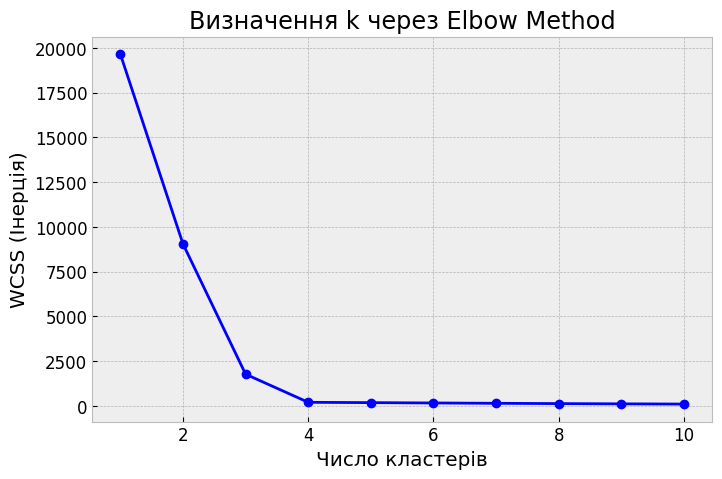

In [12]:
wcss_scores = []
k_list = range(1, 11)

for k in k_list:
    km_test = KMeans(n_clusters=k, random_state=42).fit(observations)
    wcss_scores.append(km_test.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_list, wcss_scores, 'bo-', markersize=6)
plt.title('Визначення k через Elbow Method')
plt.xlabel('Число кластерів')
plt.ylabel('WCSS (Інерція)')
plt.show()

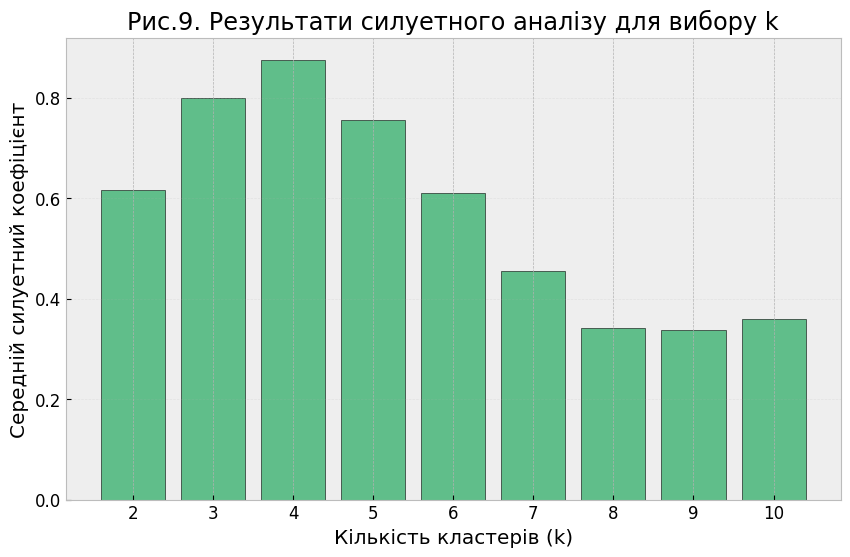

Згідно з аналізом, оптимальна кількість кластерів k = 4
Максимальне значення силуету: 0.8756


In [13]:
# Масив для зберігання значень силуету
silhouette_metrics = []
# Діапазон k від 2 до 10 (силует не розраховується для k=1)
k_candidates = range(2, 11)

for k_val in k_candidates:
    # Ініціалізація моделі з поточним k
    km_evaluator = KMeans(n_clusters=k_val, init='k-means++', n_init=10, random_state=42)
    current_labels = km_evaluator.fit_predict(observations)
    
    # Розрахунок та додавання коефіцієнта до списку
    score_val = silhouette_score(observations, current_labels)
    silhouette_metrics.append(score_val)

# Побудова стовпчикової діаграми
plt.figure(figsize=(10, 6))
plt.bar(k_candidates, silhouette_metrics, color='mediumseagreen', alpha=0.8, edgecolor='black')

plt.xlabel('Кількість кластерів (k)')
plt.ylabel('Середній силуетний коефіцієнт')
plt.title('Рис.9. Результати силуетного аналізу для вибору k')
plt.xticks(k_candidates)
plt.grid(True, alpha=0.2, axis='y')
plt.show()

# Визначення найкращого k
ideal_k_sil = k_candidates[np.argmax(silhouette_metrics)]
print(f'Згідно з аналізом, оптимальна кількість кластерів k = {ideal_k_sil}')
print(f'Максимальне значення силуету: {max(silhouette_metrics):.4f}')

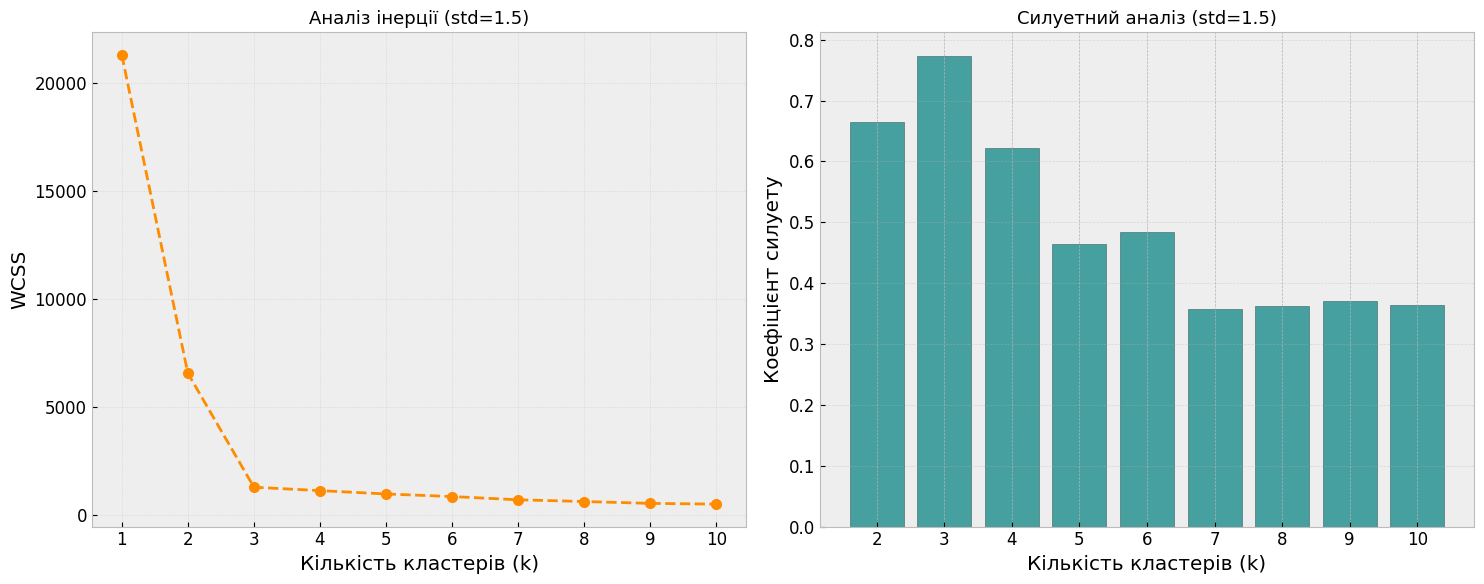

Рекомендована кількість кластерів: 3
Найкращий показник силуету (noisy): 0.7734


In [16]:
# 1. Генерація вибірки з підвищеним рівнем дисперсії (більше перекриття кластерів)
# Використовуємо 3 центри, як у прикладі
noisy_dataset, _ = make_blobs(
    n_samples=300,
    centers=3, 
    cluster_std=1.5,  # Значне розмиття меж
    random_state=42
)

# 2. Розрахунок метрики інерції для методу "ліктя"
inertia_path = []
k_values_list = range(1, 11)

for k_val in k_values_list:
    km_instance = KMeans(n_clusters=k_val, init='k-means++', n_init='auto', random_state=42)
    km_instance.fit(noisy_dataset)
    inertia_path.append(km_instance.inertia_)

# 3. Оцінка якості через силуетний індекс
silhouette_scores_list = []
k_range_test = range(2, 11)

for k_val in k_range_test:
    km_instance = KMeans(n_clusters=k_val, init='k-means++', n_init='auto', random_state=42)
    group_labels = km_instance.fit_predict(noisy_dataset)
    silhouette_scores_list.append(silhouette_score(noisy_dataset, group_labels))

# 4. Побудова порівняльних графіків для зашумлених даних
fig, (ax_inertia, ax_silh) = plt.subplots(1, 2, figsize=(15, 6))

# Візуалізація методу ліктя (Inertia)
ax_inertia.plot(
    k_values_list,
    inertia_path,
    marker='o',           
    linestyle='--',       
    color='darkorange',   
    linewidth=2,
    markersize=7,
    label='Inertia')

ax_inertia.set_title('Аналіз інерції (std=1.5)', fontsize=13)
ax_inertia.set_xlabel('Кількість кластерів (k)')
ax_inertia.set_ylabel('WCSS')
ax_inertia.set_xticks(list(k_values_list))
ax_inertia.grid(True, linestyle=':', alpha=0.5)

# Візуалізація силуетного аналізу (Silhouette)
ax_silh.bar(
    k_range_test,
    silhouette_scores_list,
    color='teal',         # Змінив колір на бірюзовий
    alpha=0.7,
    edgecolor='darkslategrey')

ax_silh.set_title('Силуетний аналіз (std=1.5)', fontsize=13)
ax_silh.set_xlabel('Кількість кластерів (k)')
ax_silh.set_ylabel('Коефіцієнт силуету')
ax_silh.set_xticks(list(k_range_test))
ax_silh.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# Фінальні висновки для розмитої вибірки
best_idx = np.argmax(silhouette_scores_list)
suggested_k = k_range_test[best_idx]
peak_silhouette = silhouette_scores_list[best_idx]

print(f"Рекомендована кількість кластерів: {suggested_k}")
print(f"Найкращий показник силуету (noisy): {peak_silhouette:.4f}")

In [20]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Завантажуємо дані
dataset_iris = load_iris()
features_iris = dataset_iris.data       # 150 зразків × 4 ознаки
labels_iris = dataset_iris.target       # мітки видів (0, 1, 2)
names_of_features = dataset_iris.feature_names

print(f'Розмір даних: {features_iris.shape}')  # (150, 4)
print(f'Ознаки: {names_of_features}')
print(f'Види ірисів: {dataset_iris.target_names}')

Розмір даних: (150, 4)
Ознаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Види ірисів: ['setosa' 'versicolor' 'virginica']


In [21]:
# Стандартизація: кожна ознака матиме середнє 0 та стд. відх. 1
std_scaler = StandardScaler()
features_scaled = std_scaler.fit_transform(features_iris)

print('До стандартизації:')
print(f'  Середні: {features_iris.mean(axis=0).round(2)}')
print(f'  Стд. відх.: {features_iris.std(axis=0).round(2)}')
print()
print('Після стандартизації:')
print(f'  Середні: {features_scaled.mean(axis=0).round(2)}')
print(f'  Стд. відх.: {features_scaled.std(axis=0).round(2)}')

До стандартизації:
  Середні: [5.84 3.06 3.76 1.2 ]
  Стд. відх.: [0.83 0.43 1.76 0.76]

Після стандартизації:
  Середні: [-0. -0. -0. -0.]
  Стд. відх.: [1. 1. 1. 1.]


In [22]:
# Зменшуємо з 4 до 2 компонент
pca_model_2d = PCA(n_components=2)
iris_pca_2d = pca_model_2d.fit_transform(features_scaled)

print(f'Розмір до PCA: {features_scaled.shape}')   # (150, 4)
print(f'Розмір після PCA: {iris_pca_2d.shape}')    # (150, 2)
print()
print(f'Пояснена дисперсія по компонентах: {pca_model_2d.explained_variance_ratio_.round(3)}')
print(f'Загальна пояснена дисперсія: {pca_model_2d.explained_variance_ratio_.sum():.1%}')

Розмір до PCA: (150, 4)
Розмір після PCA: (150, 2)

Пояснена дисперсія по компонентах: [0.73  0.229]
Загальна пояснена дисперсія: 95.8%


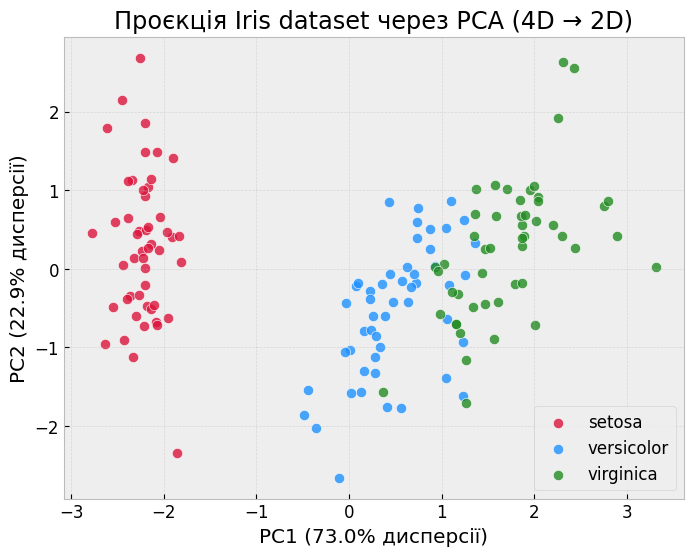

In [23]:
# Малюємо дані в новому 2D-просторі
# Використовуємо інші кольори для унікальності
palette = ['crimson', 'dodgerblue', 'forestgreen']
iris_classes = dataset_iris.target_names

plt.figure(figsize=(8, 6))
for idx, class_name in enumerate(iris_classes):
    condition = labels_iris == idx
    plt.scatter(iris_pca_2d[condition, 0], iris_pca_2d[condition, 1],
               label=class_name, color=palette[idx], alpha=0.8, s=55, edgecolor='w')

plt.xlabel(f'PC1 ({pca_model_2d.explained_variance_ratio_[0]:.1%} дисперсії)')
plt.ylabel(f'PC2 ({pca_model_2d.explained_variance_ratio_[1]:.1%} дисперсії)')
plt.title('Проєкція Iris dataset через PCA (4D → 2D)')
plt.legend()
plt.grid(True, alpha=0.4, linestyle='--')
plt.show()

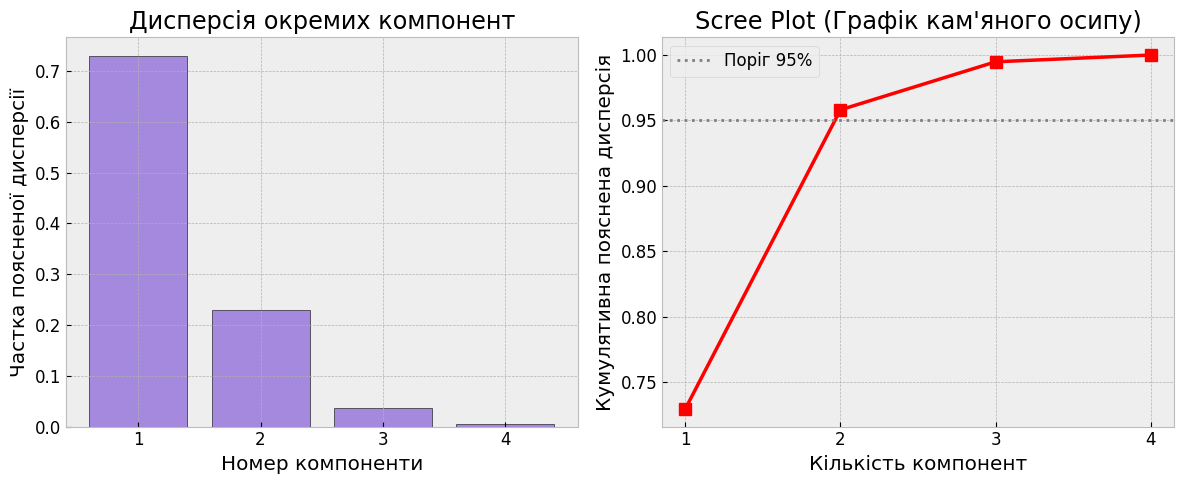

PC1: 73.0% (кумулятивно: 73.0%)
PC2: 22.9% (кумулятивно: 95.8%)
PC3: 3.7% (кумулятивно: 99.5%)
PC4: 0.5% (кумулятивно: 100.0%)


In [24]:
# PCA з усіма 4 компонентами (щоб побачити всі)
pca_all_components = PCA(n_components=4)
pca_all_components.fit(features_scaled)

variance_ratios = pca_all_components.explained_variance_ratio_
cum_variance = np.cumsum(variance_ratios)

fig, (ax_bar, ax_line) = plt.subplots(1, 2, figsize=(12, 5))

# Ліворуч: скільки пояснює кожна компонента
ax_bar.bar(range(1, 5), variance_ratios, color='mediumpurple', alpha=0.8, edgecolor='black')
ax_bar.set_xlabel('Номер компоненти')
ax_bar.set_ylabel('Частка поясненої дисперсії')
ax_bar.set_title('Дисперсія окремих компонент')
ax_bar.set_xticks(range(1, 5))

# Праворуч: кумулятивна (нагромаджена) дисперсія
ax_line.plot(range(1, 5), cum_variance, 'rs-', linewidth=2.5, markersize=8)
ax_line.axhline(y=0.95, color='gray', linestyle=':', label='Поріг 95%')
ax_line.set_xlabel('Кількість компонент')
ax_line.set_ylabel('Кумулятивна пояснена дисперсія')
ax_line.set_title('Scree Plot (Графік кам\'яного осипу)')
ax_line.set_xticks(range(1, 5))
ax_line.legend()

plt.tight_layout()
plt.show()

for i, (var, cum) in enumerate(zip(variance_ratios, cum_variance)):
    print(f'PC{i+1}: {var:.1%} (кумулятивно: {cum:.1%})')

Силуетний коефіцієнт після PCA: 0.5092


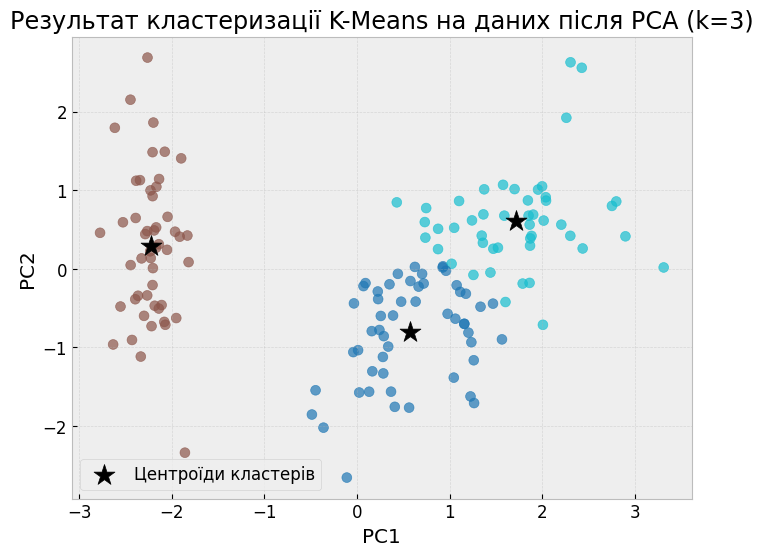

In [25]:
# Застосовуємо K-Means (k=3) до даних після PCA
km_pca = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
pca_cluster_labels = km_pca.fit_predict(iris_pca_2d)

# Обчислюємо силуетний коефіцієнт
sil_pca = silhouette_score(iris_pca_2d, pca_cluster_labels)
print(f"Силуетний коефіцієнт після PCA: {sil_pca:.4f}")

# Візуалізація кластерів, знайдених алгоритмом
plt.figure(figsize=(8, 6))
plt.scatter(iris_pca_2d[:, 0], iris_pca_2d[:, 1], c=pca_cluster_labels, cmap='tab10', s=50, alpha=0.7)

# Додаємо центроїди
pca_centroids = km_pca.cluster_centers_
plt.scatter(pca_centroids[:, 0], pca_centroids[:, 1], c='black', marker='*', s=250, label='Центроїди кластерів')

plt.title('Результат кластеризації K-Means на даних після PCA (k=3)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Наша тестова міні-колекція текстів
mini_corpus = [
    'кіт спить кіт',
    'собака біжить',
    'кіт біжить'
]

# Ініціалізація та розрахунок TF-IDF матриці
tfidf_engine = TfidfVectorizer()
matrix_tfidf = tfidf_engine.fit_transform(mini_corpus)

# Вивід результатів для аналізу
print('Сформований словник:', tfidf_engine.get_feature_names_out())
print('\nМатриця ваг TF-IDF (рядки = документи, стовпці = слова):')

# Оформлення у вигляді зручної таблиці (DataFrame)
df_tfidf = pd.DataFrame(
    matrix_tfidf.toarray(),
    columns=tfidf_engine.get_feature_names_out(),
    index=['Док1: кіт спить кіт', 'Док2: собака біжить', 'Док3: кіт біжить']
)
print(df_tfidf.round(3))

Сформований словник: ['біжить' 'кіт' 'собака' 'спить']

Матриця ваг TF-IDF (рядки = документи, стовпці = слова):
                     біжить    кіт  собака  спить
Док1: кіт спить кіт   0.000  0.836   0.000  0.549
Док2: собака біжить   0.605  0.000   0.796  0.000
Док3: кіт біжить      0.707  0.707   0.000  0.000


In [27]:
# Базовий набір новинних заголовків
base_headlines = [
    # Блок: Спорт
    'збірна виграла чемпіонат з футболу',
    'гравець забив гол у фіналі матчу',
    'тренер оголосив склад на турнір',
    'клуб підписав новий контракт з нападником',
    'чемпіонат світу з плавання відкриється влітку',
    # Блок: Технології
    'компанія представила новий штучний інтелект',
    'стартап розробив додаток для аналізу даних',
    'вчені навчили нейромережу розпізнавати мову',
    'нова модель процесора вдвічі швидша',
    'технологічна конференція зібрала тисячі учасників',
    # Блок: Економіка
    'центральний банк знизив облікову ставку',
    'інфляція зросла на два відсотки за місяць',
    'біржовий індекс оновив історичний максимум',
    'уряд затвердив новий бюджет на наступний рік',
    'експорт зерна збільшився на тридцять відсотків',
]

# Векторизація базового набору
news_vectorizer = TfidfVectorizer()
features_text = news_vectorizer.fit_transform(base_headlines)

# Перевірка розмірності: 15 документів на N унікальних слів
print(f'Розмірність текстової матриці: {features_text.shape}')

Розмірність текстової матриці: (15, 74)


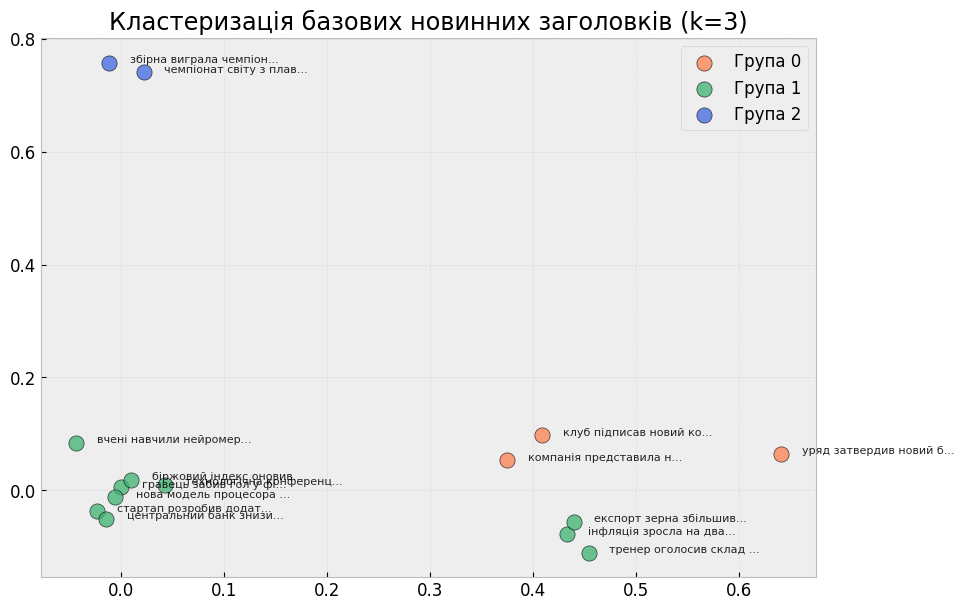


=== Тематична Група 0 ===
  -> клуб підписав новий контракт з нападником
  -> компанія представила новий штучний інтелект
  -> уряд затвердив новий бюджет на наступний рік

=== Тематична Група 1 ===
  -> гравець забив гол у фіналі матчу
  -> тренер оголосив склад на турнір
  -> стартап розробив додаток для аналізу даних
  -> вчені навчили нейромережу розпізнавати мову
  -> нова модель процесора вдвічі швидша
  -> технологічна конференція зібрала тисячі учасників
  -> центральний банк знизив облікову ставку
  -> інфляція зросла на два відсотки за місяць
  -> біржовий індекс оновив історичний максимум
  -> експорт зерна збільшився на тридцять відсотків

=== Тематична Група 2 ===
  -> збірна виграла чемпіонат з футболу
  -> чемпіонат світу з плавання відкриється влітку


In [28]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 1. Зменшення розмірності для побудови графіка (аналог PCA для текстів)
svd_reducer = TruncatedSVD(n_components=2, random_state=42)
text_2d_proj = svd_reducer.fit_transform(features_text)

# 2. Навчання моделі K-Means на 3 тематичні групи
km_news = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
news_clusters = km_news.fit_predict(features_text)

# 3. Візуалізація результату
cluster_palette = ['coral', 'mediumseagreen', 'royalblue']

plt.figure(figsize=(10, 7))
for cluster_id in range(3):
    condition = news_clusters == cluster_id
    plt.scatter(text_2d_proj[condition, 0], text_2d_proj[condition, 1],
                color=cluster_palette[cluster_id], s=120, alpha=0.75, 
                edgecolors='k', label=f'Група {cluster_id}')

# Додаємо текстові підписи до точок
for idx, text in enumerate(base_headlines):
    plt.annotate(text[:22] + '...', (text_2d_proj[idx, 0] + 0.02, text_2d_proj[idx, 1]),
                 fontsize=8, alpha=0.85)

plt.title('Кластеризація базових новинних заголовків (k=3)')
plt.legend()
plt.grid(True, alpha=0.3, linestyle='--')
plt.show()

# 4. Вивід згрупованих заголовків у консоль
for c_id in range(3):
    print(f'\n=== Тематична Група {c_id} ===')
    for doc_idx, headline in enumerate(base_headlines):
        if news_clusters[doc_idx] == c_id:
            print(f'  -> {headline}')

Нова розмірність матриці: (20, 100)


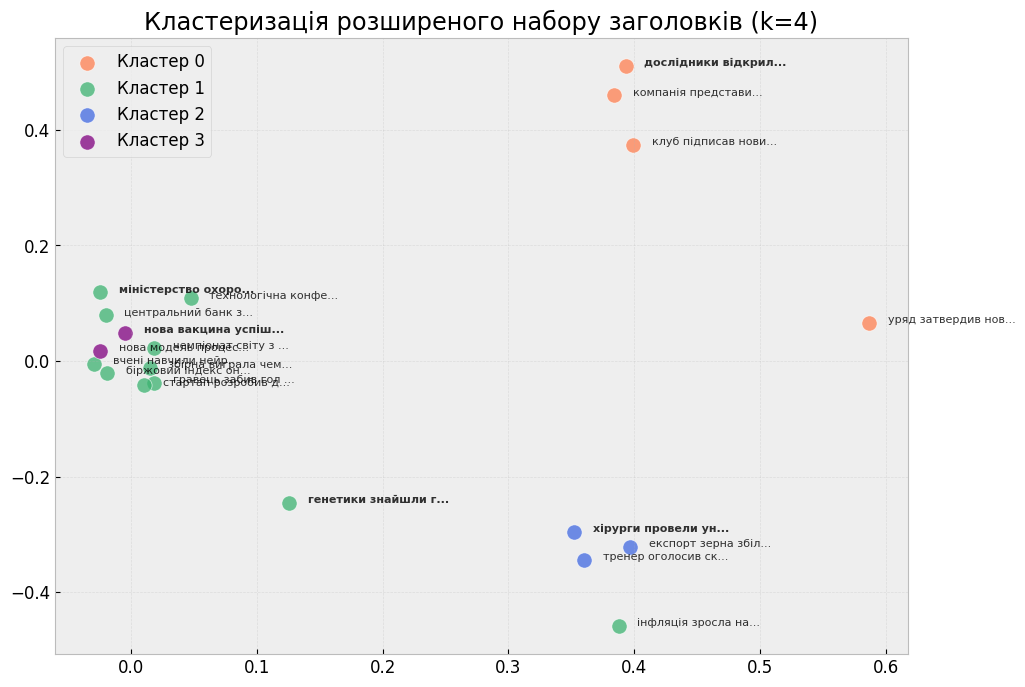

РЕЗУЛЬТАТ РОЗПОДІЛУ З НОВИМИ ДАНИМИ:

--- Кластер 0 ---
  клуб підписав новий контракт з нападником
  компанія представила новий штучний інтелект
  уряд затвердив новий бюджет на наступний рік
  [НОВЕ] дослідники відкрили новий вид антибіотиків

--- Кластер 1 ---
  збірна виграла чемпіонат з футболу
  гравець забив гол у фіналі матчу
  чемпіонат світу з плавання відкриється влітку
  стартап розробив додаток для аналізу даних
  вчені навчили нейромережу розпізнавати мову
  технологічна конференція зібрала тисячі учасників
  центральний банк знизив облікову ставку
  інфляція зросла на два відсотки за місяць
  біржовий індекс оновив історичний максимум
  [НОВЕ] міністерство охорони здоровя оновило протоколи лікування
  [НОВЕ] генетики знайшли ген що відповідає за довголіття

--- Кластер 2 ---
  тренер оголосив склад на турнір
  експорт зерна збільшився на тридцять відсотків
  [НОВЕ] хірурги провели унікальну операцію на серці

--- Кластер 3 ---
  нова модель процесора вдвічі швидша
  [НОВ

In [29]:
# 5 унікальних заголовків (Тематика: Медицина)
my_custom_headlines = [
    'хірурги провели унікальну операцію на серці',
    'нова вакцина успішно пройшла клінічні випробування',
    'дослідники відкрили новий вид антибіотиків',
    'міністерство охорони здоровя оновило протоколи лікування',
    'генетики знайшли ген що відповідає за довголіття'
]

# Об'єднуємо списки
extended_headlines = base_headlines + my_custom_headlines

# 1. Повторна векторизація всього набору
vec_extended = TfidfVectorizer()
X_extended = vec_extended.fit_transform(extended_headlines)
print(f'Нова розмірність матриці: {X_extended.shape}')

# 2. Зменшення розмірності
svd_ext = TruncatedSVD(n_components=2, random_state=42)
X_ext_2d = svd_ext.fit_transform(X_extended)

# 3. Кластеризація (встановлюємо k=4, бо додали нову тему)
km_ext = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
labels_ext = km_ext.fit_predict(X_extended)

# 4. Візуалізація
ext_colors = ['coral', 'mediumseagreen', 'royalblue', 'purple']

plt.figure(figsize=(11, 8))
for i in range(4):
    mask = labels_ext == i
    plt.scatter(X_ext_2d[mask, 0], X_ext_2d[mask, 1],
                color=ext_colors[i], s=120, alpha=0.75, edgecolors='w', label=f'Кластер {i}')

for i, txt in enumerate(extended_headlines):
    # Виділимо нові заголовки жирним шрифтом на графіку
    weight = 'bold' if txt in my_custom_headlines else 'normal'
    plt.annotate(txt[:18] + '...', (X_ext_2d[i, 0] + 0.015, X_ext_2d[i, 1]),
                 fontsize=8, alpha=0.8, weight=weight)

plt.title('Кластеризація розширеного набору заголовків (k=4)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Вивід результату
print("РЕЗУЛЬТАТ РОЗПОДІЛУ З НОВИМИ ДАНИМИ:")
for c in range(4):
    print(f'\n--- Кластер {c} ---')
    for i, h in enumerate(extended_headlines):
        if labels_ext[i] == c:
            # Позначаємо свої новини зірочкою
            mark = "[НОВЕ] " if h in my_custom_headlines else ""
            print(f'  {mark}{h}')

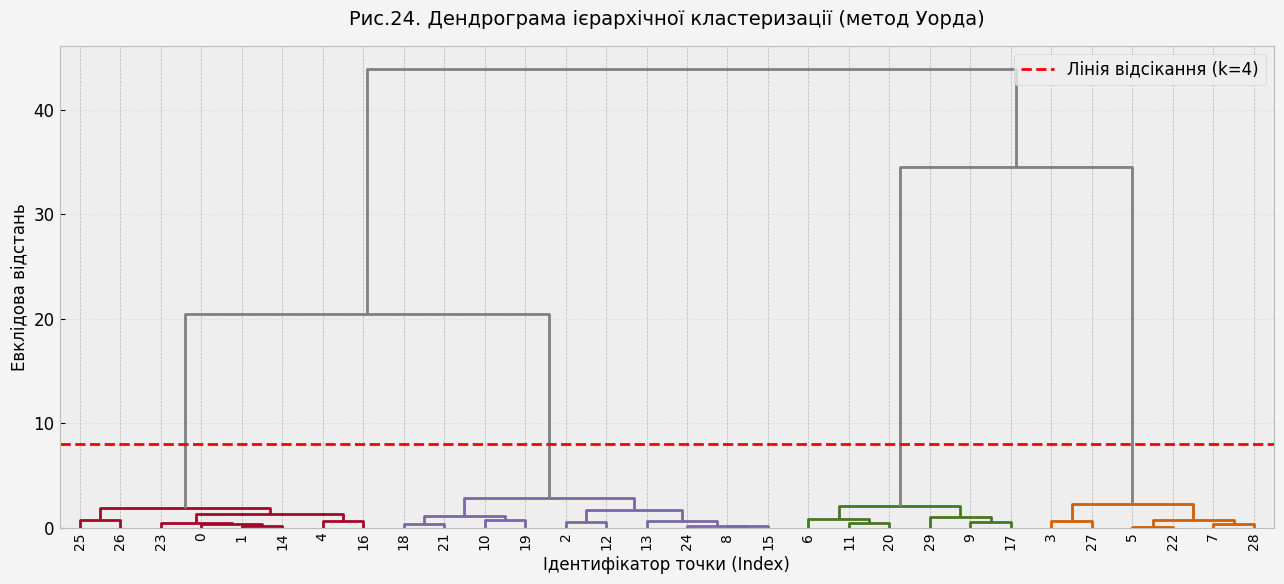

In [30]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# 1. Беремо невелику підвибірку (перші 30 точок), щоб дерево було читабельним
sample_for_tree = observations[:30]

# 2. Будуємо матрицю відстаней за методом Уорда (Ward)
# Метод Уорда мінімізує дисперсію всередині кластерів при їх об'єднанні
linkage_ward_matrix = linkage(sample_for_tree, method='ward')

# 3. Візуалізація дендрограми
plt.figure(figsize=(13, 6), facecolor='#f4f4f4')
tree_plot = dendrogram(
    linkage_ward_matrix,
    leaf_rotation=90,
    leaf_font_size=10,
    color_threshold=8,  # Поріг кольору для відокремлення гілок
    above_threshold_color='gray'
)

# Додаємо лінію розрізу (приблизно на рівні, де утворюється 4 гілки)
plt.axhline(y=8, color='red', linestyle='--', linewidth=2, label='Лінія відсікання (k=4)')

plt.title('Рис.24. Дендрограма ієрархічної кластеризації (метод Уорда)', fontsize=14, pad=15)
plt.xlabel('Ідентифікатор точки (Index)', fontsize=12)
plt.ylabel('Евклідова відстань', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

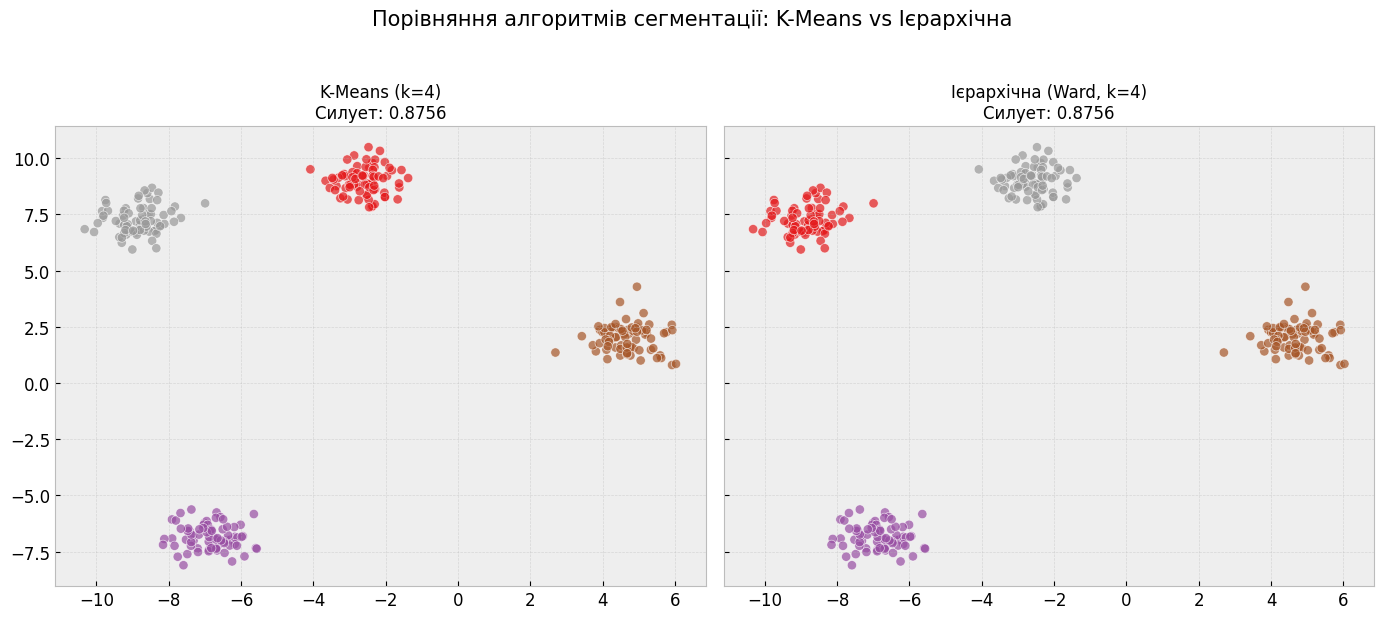

Силует K-Means: 0.8756
Силует Ієрархічної (Ward): 0.8756
Різниця в якості: 0.00000


In [31]:
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score

# 1. Ієрархічна кластеризація (Агломеративна) на всій вибірці для k=4
model_agglo = AgglomerativeClustering(n_clusters=4, linkage='ward')
labels_agglo = model_agglo.fit_predict(observations)

# 2. K-Means для порівняння (також k=4)
model_km_base = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=42)
labels_km_base = model_km_base.fit_predict(observations)

# Розрахунок метрик
sil_agglo = silhouette_score(observations, labels_agglo)
sil_km = silhouette_score(observations, labels_km_base)

# 3. Візуальне порівняння результатів
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Графік K-Means
ax_left.scatter(observations[:, 0], observations[:, 1], c=labels_km_base, cmap='Set1', s=45, alpha=0.7, edgecolors='white')
ax_left.set_title(f'K-Means (k=4)\nСилует: {sil_km:.4f}', fontsize=12)
ax_left.grid(True, linestyle='--', alpha=0.4)

# Графік Ієрархічної кластеризації
ax_right.scatter(observations[:, 0], observations[:, 1], c=labels_agglo, cmap='Set1', s=45, alpha=0.7, edgecolors='white')
ax_right.set_title(f'Ієрархічна (Ward, k=4)\nСилует: {sil_agglo:.4f}', fontsize=12)
ax_right.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Порівняння алгоритмів сегментації: K-Means vs Ієрархічна', fontsize=15, y=1.03)
plt.tight_layout()
plt.show()

# Вивід у консоль
print(f"Силует K-Means: {sil_km:.4f}")
print(f"Силует Ієрархічної (Ward): {sil_agglo:.4f}")
print(f"Різниця в якості: {abs(sil_km - sil_agglo):.5f}")

Метод 'single  ' | Силуетний коефіцієнт: 0.8756
Метод 'complete' | Силуетний коефіцієнт: 0.8756
Метод 'average ' | Силуетний коефіцієнт: 0.8756


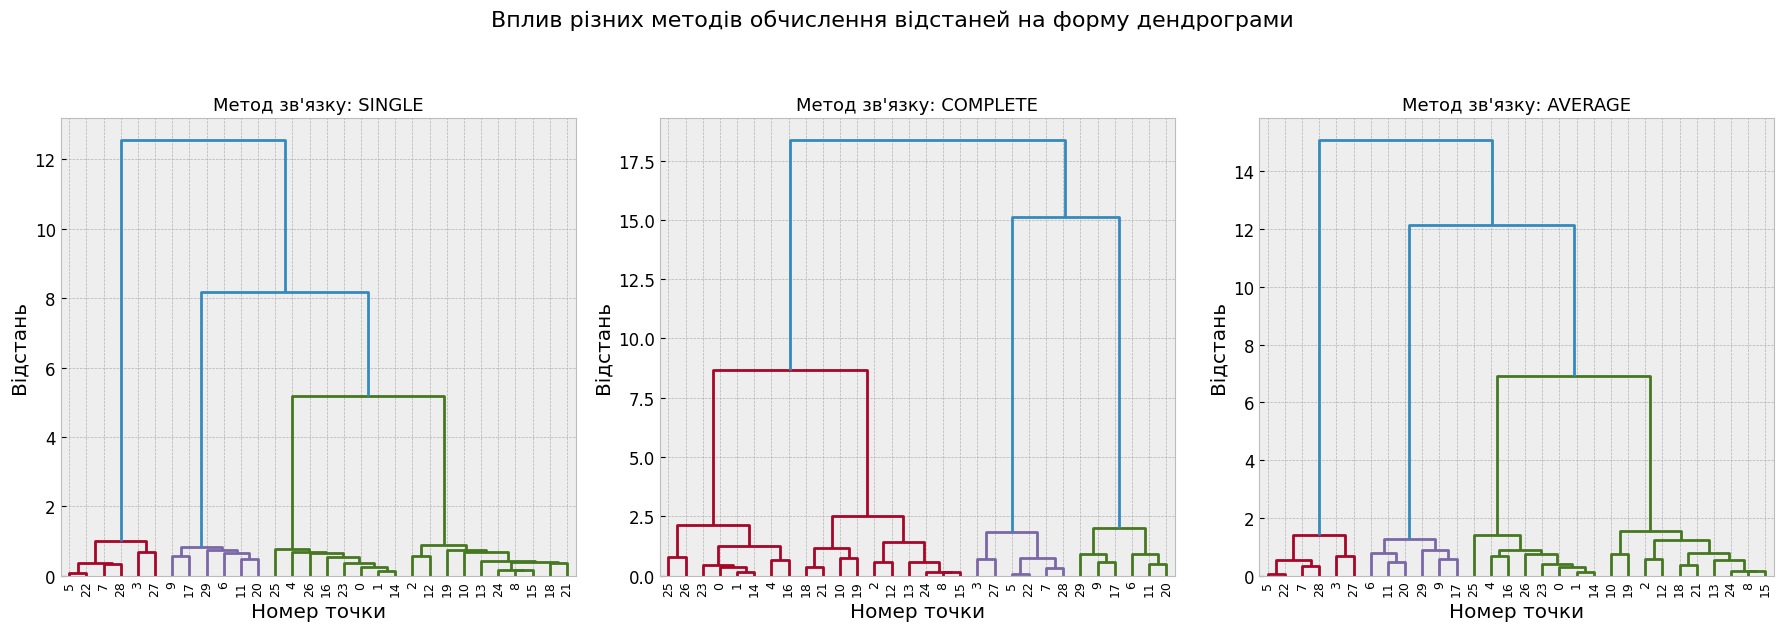

In [32]:
# 1. Налаштування параметрів для експерименту
methods_to_test = ['single', 'complete', 'average']
subset_30 = observations[:30]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, link_method in enumerate(methods_to_test):
    # 2. Побудова матриці зв'язків та дендрограми для поточного методу
    matrix_l = linkage(subset_30, method=link_method)
    
    dendrogram(
        matrix_l,
        ax=axes[i],
        leaf_rotation=90,
        leaf_font_size=9,
        # Налаштування кольору для кращої видимості
        color_threshold=0.6 * max(matrix_l[:, 2]) 
    )
    
    axes[i].set_title(f"Метод зв'язку: {link_method.upper()}", fontsize=13)
    axes[i].set_xlabel("Номер точки")
    axes[i].set_ylabel("Відстань")

    # 3. Розрахунок силуету на ПОВНИХ даних (k=4) для цього методу
    test_agglo = AgglomerativeClustering(n_clusters=4, linkage=link_method)
    test_labels = test_agglo.fit_predict(observations)
    
    score_val = silhouette_score(observations, test_labels)
    print(f"Метод '{link_method:8}' | Силуетний коефіцієнт: {score_val:.4f}")

plt.suptitle("Вплив різних методів обчислення відстаней на форму дендрограми", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

PCA: Сумарна збережена дисперсія (2 компоненти з 13): 55.4%



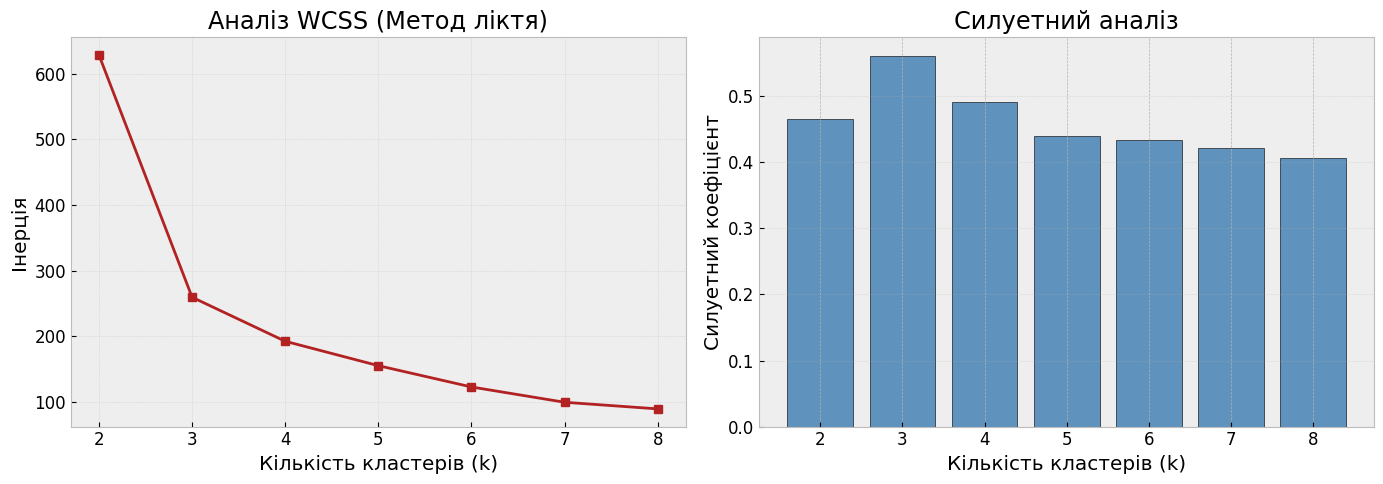

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Завантаження даних
dataset_wine = load_wine()
features_wine = dataset_wine.data       # 178 зразків, 13 хімічних ознак
true_labels = dataset_wine.target       # Реальні класи (3 сорти вина)

# 2. Стандартизація даних (Z-score)
# Це критично перед PCA, щоб жодна з 13 ознак не домінувала через масштаб
scaler_wine = StandardScaler()
scaled_wine = scaler_wine.fit_transform(features_wine)

# 3. Метод головних компонент (PCA)
pca_wine = PCA(n_components=2)
wine_2d = pca_wine.fit_transform(scaled_wine)

variance_retained = pca_wine.explained_variance_ratio_.sum()
print(f"PCA: Сумарна збережена дисперсія (2 компоненти з 13): {variance_retained:.1%}\n")

# 4. Вибір оптимального k (Elbow Method + Silhouette)
inertia_metrics = []
sil_metrics = []
k_range_wine = range(2, 9)

for k_val in k_range_wine:
    # Навчаємо модель для кожного k
    km_temp = KMeans(n_clusters=k_val, init='k-means++', n_init=10, random_state=42)
    temp_labels = km_temp.fit_predict(wine_2d)
    
    # Зберігаємо результати
    inertia_metrics.append(km_temp.inertia_)
    sil_metrics.append(silhouette_score(wine_2d, temp_labels))

# Візуалізація результатів вибору k
fig, (ax_wcss, ax_silhouette) = plt.subplots(1, 2, figsize=(14, 5))

# Лівий графік: Інерція
ax_wcss.plot(k_range_wine, inertia_metrics, marker='s', color='firebrick', linewidth=2)
ax_wcss.set_title('Аналіз WCSS (Метод ліктя)')
ax_wcss.set_xlabel('Кількість кластерів (k)')
ax_wcss.set_ylabel('Інерція')
ax_wcss.grid(True, linestyle=':', alpha=0.6)

# Правий графік: Силует
ax_silhouette.bar(k_range_wine, sil_metrics, color='steelblue', alpha=0.85, edgecolor='black')
ax_silhouette.set_title('Силуетний аналіз')
ax_silhouette.set_xlabel('Кількість кластерів (k)')
ax_silhouette.set_ylabel('Силуетний коефіцієнт')
ax_silhouette.grid(True, linestyle=':', alpha=0.6, axis='y')

plt.tight_layout()
plt.show()

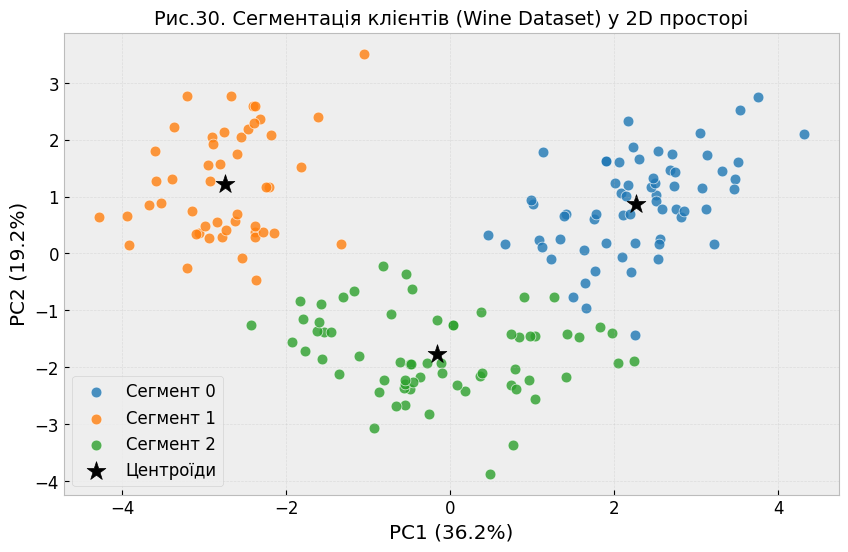

Правильно розпізнано зразків: 172 із 178
Підсумкова точність кластеризації: 96.63%


In [34]:
# 5. K-Means з оптимальним k=3 (визначено за графіками)
best_k_wine = 3
km_final = KMeans(n_clusters=best_k_wine, init='k-means++', n_init=10, random_state=42)
predicted_wine_clusters = km_final.fit_predict(wine_2d)

# 6. Візуалізація в PCA-просторі (Рис.30)
plt.figure(figsize=(10, 6))
# Кастомна палітра для вина
wine_colors = ['#1f77b4', '#ff7f0e', '#2ca02c'] 

for cluster_idx in range(best_k_wine):
    mask = (predicted_wine_clusters == cluster_idx)
    plt.scatter(
        wine_2d[mask, 0], 
        wine_2d[mask, 1], 
        c=wine_colors[cluster_idx], 
        s=60, 
        alpha=0.8, 
        edgecolors='w',
        label=f'Сегмент {cluster_idx}'
    )

# Центроїди
wine_centroids = km_final.cluster_centers_
plt.scatter(wine_centroids[:, 0], wine_centroids[:, 1], c='black', marker='*', s=200, label='Центроїди')

plt.title('Рис.30. Сегментація клієнтів (Wine Dataset) у 2D просторі', fontsize=14)
plt.xlabel(f'PC1 ({pca_wine.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca_wine.explained_variance_ratio_[1]:.1%})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Валідація: Порівняння з реальними мітками
# Алгоритм не знає справжніх міток, тому ми "вирівнюємо" знайдені кластери з реальними (majority vote)
mapped_labels = np.zeros_like(predicted_wine_clusters)

for cluster_idx in range(best_k_wine):
    mask = (predicted_wine_clusters == cluster_idx)
    # Шукаємо, який реальний клас зустрічається найчастіше в цьому кластері
    dominant_class = np.bincount(true_labels[mask]).argmax()
    mapped_labels[mask] = dominant_class

# Розрахунок точності (Accuracy)
correct_predictions = np.sum(mapped_labels == true_labels)
total_samples = len(true_labels)
final_accuracy = correct_predictions / total_samples

print(f"Правильно розпізнано зразків: {correct_predictions} із {total_samples}")
print(f"Підсумкова точність кластеризації: {final_accuracy:.2%}")